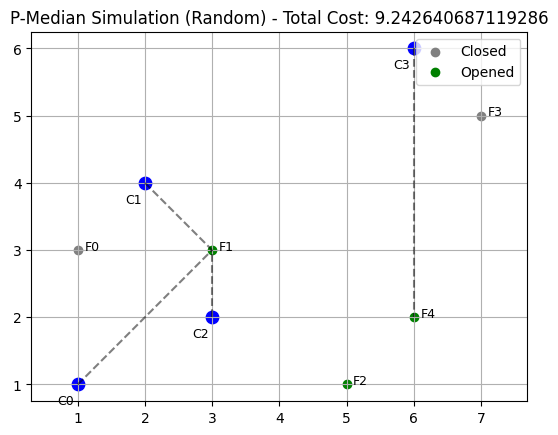

In [23]:
import random
import math
import matplotlib.pyplot as plt

customers = [(1, 1), (2, 4), (3, 2), (6, 6)]
facilities = [(1, 3), (3, 3), (5, 1), (7, 5), (6, 2)]
p = 3  #From paper 1 P = no of facilities
def distance(a, b):
    dx = a[0] - b[0]
    dy = a[1] - b[1]
    return math.sqrt(dx*dx + dy*dy)

#Random P facilities
total_facilities = len(facilities)
open_indices = random.sample(range(total_facilities), p)
open_facilities = []
for i in open_indices:
    open_facilities.append(facilities[i])

#Giving a node a facility
assignments = []
total_cost = 0

for cust in customers:
    best_fac = None
    best_dist = float('inf')

    for fac in open_facilities:
        d = distance(cust, fac)
        if d < best_dist:
            best_dist = d
            best_fac = fac

    assignments.append((cust, best_fac))
    total_cost += best_dist

#Plots
for pair in assignments:
    cust = pair[0]
    fac = pair[1]
    plt.plot([cust[0], fac[0]], [cust[1], fac[1]], 'k--', alpha=0.5)
#Facilities plt
for i in range(len(facilities)):
    x, y = facilities[i]
    if i in open_indices:
        plt.scatter(x, y, color='green',  label='Opened' if i == open_indices[0] else "")
    else:
        plt.scatter(x, y, color='gray',  label='Closed' if i == 0 else "")
    plt.text(x + 0.1, y, f"F{i}", fontsize=9)

# Plt customers
for i in range(len(customers)):
    x, y = customers[i]
    plt.scatter(x, y, color='blue', s=80)
    plt.text(x - 0.3, y - 0.3, f"C{i}", fontsize=9)

plt.title(f"P-Median Simulation (Random) - Total Cost: {total_cost}")
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()


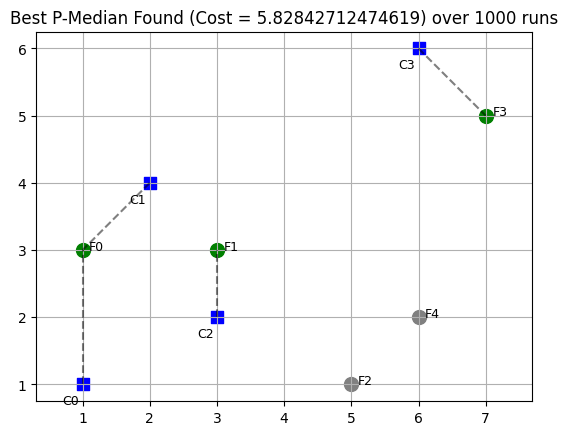

In [24]:
import random
import math
import matplotlib.pyplot as plt
#Data
customers = [(1, 1), (2, 4), (3, 2), (6, 6)]
facilities = [(1, 3), (3, 3), (5, 1), (7, 5), (6, 2)]
p = 3
iterations = 1000  # Try this many random solutions

def distance(a, b):
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

#Find Best Solution via Random Search
best_cost = float('inf')
best_open_indices = []
best_assignments = []

for _ in range(iterations):
    open_indices = random.sample(range(len(facilities)), p)
    open_facilities = [facilities[i] for i in open_indices]
    total_cost = 0
    assignments = []

    for cust in customers:
        best_fac = min(open_facilities, key=lambda f: distance(cust, f))
        total_cost += distance(cust, best_fac)
        assignments.append((cust, best_fac))

    if total_cost < best_cost:
        best_cost = total_cost
        best_open_indices = open_indices[:]
        best_assignments = assignments[:]

# --- Plot Best Result ---
for cust, fac in best_assignments:
    plt.plot([cust[0], fac[0]], [cust[1], fac[1]], 'k--', alpha=0.5)

for i, (x, y) in enumerate(facilities):
    color = 'green' if i in best_open_indices else 'gray'
    plt.scatter(x, y, color=color, s=100, marker='o')
    plt.text(x+0.1, y, f"F{i}", fontsize=9)

for i, (x, y) in enumerate(customers):
    plt.scatter(x, y, color='blue', s=80, marker='s')
    plt.text(x-0.3, y-0.3, f"C{i}", fontsize=9)

plt.title(f"Best P-Median Found (Cost = {best_cost}) over {iterations} runs")
plt.grid(True)
plt.axis('equal')
plt.show()


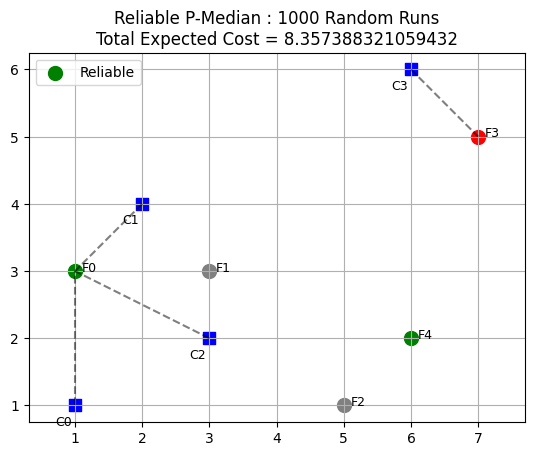

In [25]:
#RELIABLE pMP CODE

import random
import math
import matplotlib.pyplot as plt

customers = [(1, 1), (2, 4), (3, 2), (6, 6)]
facilities = [(1, 3), (3, 3), (5, 1), (7, 5), (6, 2)]


facility_types = ['reliable', 'unreliable', 'reliable', 'unreliable', 'reliable']
failure_probs = [0.0, 0.3, 0.0, 0.5, 0.0]

p = 3  
iterations = 1000  

def distance(a, b):
    dx = a[0] - b[0]
    dy = a[1] - b[1]
    return math.sqrt(dx * dx + dy * dy)

# track of the best solution found
best_cost = float('inf')
best_open_indices = []
best_assignments = []


for _ in range(iterations):
    open_indices = random.sample(range(len(facilities)), p)
    open_facilities = [facilities[i] for i in open_indices]
    open_types = [facility_types[i] for i in open_indices]
    open_probs = [failure_probs[i] for i in open_indices]

    total_cost = 0
    assignments = []

    for cust in customers:
        best_expected = float('inf')
        best_fac = None

        for i in range(p):
            fac = open_facilities[i]
            ftype = open_types[i]
            q = open_probs[i]
            d = distance(cust, fac)

            if ftype == 'reliable':
                expected = d
            else:
                fallback_dist = float('inf')
                for j in range(p):
                    if open_types[j] == 'reliable':
                        fallback_dist = min(fallback_dist, distance(cust, open_facilities[j]))
                expected = (1 - q) * d + q * fallback_dist

            if expected < best_expected:
                best_expected = expected
                best_fac = fac

        assignments.append((cust, best_fac))
        total_cost += best_expected

    if total_cost < best_cost:
        best_cost = total_cost
        best_open_indices = open_indices[:]
        best_assignments = assignments[:]


for cust, fac in best_assignments:
    plt.plot([cust[0], fac[0]], [cust[1], fac[1]], 'k--', alpha=0.5)

for i, (x, y) in enumerate(facilities):
    if i in best_open_indices:
        if facility_types[i] == 'reliable':
            plt.scatter(x, y, color='green', s=100, label='Reliable' if i == best_open_indices[0] else "")
        else:
            plt.scatter(x, y, color='red', s=100, label='Unreliable' if i == best_open_indices[0] else "")
    else:
        plt.scatter(x, y, color='gray', s=100)

    plt.text(x + 0.1, y, f"F{i}", fontsize=9)

for i, (x, y) in enumerate(customers):
    plt.scatter(x, y, color='blue', s=80, marker='s')
    plt.text(x - 0.3, y - 0.3, f"C{i}", fontsize=9)

plt.title(f"Reliable P-Median : {iterations} Random Runs\nTotal Expected Cost = {best_cost}")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()
